In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Assuming your data is in a CSV file
# If your data is already in a DataFrame, you can skip this step
df = pd.read_csv('/content/matrix_operations_processed.csv')

# For demonstration purposes, I'll recreate a sample dataframe based on your information
# In practice, you would use your actual dataframe here
def create_sample_df(n_samples=6018):
    operations = ['addition', 'duplication', 'multiplication', 'elemwise_multiplication']
    matrix_sizes = np.random.randint(100, 853, n_samples)
    variable_types = np.random.randint(0, 2, n_samples)
    num_operations = np.random.randint(10000, 1631011, n_samples)

    operations_list = []
    for op in operations:
        operations_list.extend([op] * (n_samples // 4))

    # Add any remaining samples to maintain exact count
    for i in range(n_samples - len(operations_list)):
        operations_list.append(operations[i % 4])

    # Create encoded operation column
    operation_encoded = []
    for op in operations_list:
        if op == 'addition':
            operation_encoded.append(0)
        elif op == 'duplication':
            operation_encoded.append(1)
        elif op == 'multiplication':
            operation_encoded.append(2)
        else:  # elemwise_multiplication
            operation_encoded.append(3)

    # Create size_operations_interaction
    size_operations_interaction = matrix_sizes * num_operations

    # Create log_num_operations
    log_num_operations = np.log(num_operations)

    # Create optimal_thread based on the features
    # This is just an example - your actual data has real optimal thread values
    optimal_thread = np.clip(
        (matrix_sizes / 100) + (num_operations / 500000) + (variable_types * 2) + np.random.randint(0, 3, n_samples),
        1, 16
    ).astype(int)

    df = pd.DataFrame({
        'operation': operations_list,
        'matrix_size': matrix_sizes,
        'variable_type': variable_types,
        'num_operations': num_operations,
        'optimal_thread': optimal_thread,
        'operation_encoded': operation_encoded,
        'size_operations_interaction': size_operations_interaction,
        'log_num_operations': log_num_operations
    })

    return df

# Either use your actual dataframe or this sample one
# Comment out the next line if using your own dataframe
#df = create_sample_df()

# Display dataset information
print("Dataset Information:")
print(df.info())
print("\nDataset Statistics:")
print(df.describe())
print("\nOperation Distribution:")
print(df['operation'].value_counts())

# Visualize data
plt.figure(figsize=(15, 10))

# Distribution of optimal thread counts
plt.subplot(2, 3, 1)
sns.histplot(df['optimal_thread'], kde=True)
plt.title('Distribution of Optimal Thread Counts')

# Matrix size vs optimal thread
plt.subplot(2, 3, 2)
sns.scatterplot(x='matrix_size', y='optimal_thread', hue='operation', data=df, alpha=0.5)
plt.title('Matrix Size vs Optimal Thread Count')

# Number of operations vs optimal thread
plt.subplot(2, 3, 3)
sns.scatterplot(x='log_num_operations', y='optimal_thread', hue='operation', data=df, alpha=0.5)
plt.title('Log(Num Operations) vs Optimal Thread Count')

# Variable type vs optimal thread
plt.subplot(2, 3, 4)
sns.boxplot(x='variable_type', y='optimal_thread', data=df)
plt.title('Variable Type vs Optimal Thread Count')

# Operation type vs optimal thread
plt.subplot(2, 3, 5)
sns.boxplot(x='operation', y='optimal_thread', data=df)
plt.xticks(rotation=45)
plt.title('Operation Type vs Optimal Thread Count')

# Correlation heatmap
plt.subplot(2, 3, 6)
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation = numeric_df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')

plt.tight_layout()
plt.savefig('data_visualization.png', dpi=300)
plt.close()

# Feature Engineering
print("\nPerforming feature engineering...")

# Create feature matrix and target vector
X = df[['matrix_size', 'variable_type', 'num_operations', 'operation_encoded',
        'size_operations_interaction', 'log_num_operations']]

# You could also use the original 'operation' column with one-hot encoding
# X = df[['matrix_size', 'variable_type', 'num_operations', 'operation',
#         'size_operations_interaction', 'log_num_operations']]

y = df['optimal_thread']

# Create additional features (uncomment if you want to add more features)
X['matrix_size_squared'] = X['matrix_size'] ** 2
X['size_variable_interaction'] = X['matrix_size'] * X['variable_type']
X['operation_size_ratio'] = X['matrix_size'] / (X['operation_encoded'] + 1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define column transformer for preprocessing
categorical_features = []
numerical_features = ['matrix_size', 'variable_type', 'num_operations', 'operation_encoded',
                       'size_operations_interaction', 'log_num_operations',
                       'matrix_size_squared', 'size_variable_interaction', 'operation_size_ratio']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ], remainder='passthrough')

# Define models and their hyperparameters for grid search
models = {
    'XGBoost': {
        'model': xgb.XGBRegressor(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1],
            'max_depth': [3, 6, 9],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0]
        }
    },
    'LightGBM': {
        'model': lgb.LGBMRegressor(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1],
            'max_depth': [3, 6, 9],
            'num_leaves': [31, 63, 127]
        }
    },
    'RandomForest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingRegressor(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1],
            'max_depth': [3, 6, 9],
            'subsample': [0.8, 1.0]
        }
    },
    'NeuralNetwork': {
        'model': Pipeline([('scaler', StandardScaler()), ('mlp', MLPRegressor(random_state=42))]),
        'params': {
            'mlp__hidden_layer_sizes': [(64, 32), (128, 64, 32)],
            'mlp__alpha': [0.0001, 0.001],
            'mlp__learning_rate': ['constant', 'adaptive'],
            'mlp__max_iter': [1000]
        }
    },
    'SVR': {
        'model': SVR(),
        'params': {
            'C': [1, 10, 100],
            'gamma': ['scale', 'auto'],
            'kernel': ['rbf', 'poly']
        }
    }
}

# Function to evaluate models
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Calculate "off-by-one" accuracy (predictions within ±1 of actual)
    off_by_one = np.mean(np.abs(y_test - np.round(y_pred)) <= 1)

    # Calculate exact accuracy for thread count (treating as classification)
    exact_accuracy = np.mean(np.round(y_pred) == y_test)

    return {
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'off_by_one_accuracy': off_by_one,
        'exact_accuracy': exact_accuracy
    }

# Basic model evaluation without grid search
print("\nBasic model evaluation:")
basic_results = {}

for name, model_info in models.items():
    print(f"Evaluating {name}...")
    if name == 'NeuralNetwork':
        model = model_info['model']
    else:
        model = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model_info['model'])
        ])

    basic_results[name] = evaluate_model(model, X_train, X_test, y_train, y_test)
    print(f"{name} - RMSE: {basic_results[name]['rmse']:.4f}, R²: {basic_results[name]['r2']:.4f}, "
          f"Off-by-One Accuracy: {basic_results[name]['off_by_one_accuracy']:.4f}")

# Grid search for best model (uncomment to run - this can take time)
print("\nPerforming grid search for model optimization...")
best_models = {}
grid_search_results = {}

for name, model_info in models.items():
    print(f"Grid search for {name}...")
    if name == 'NeuralNetwork':
        model = model_info['model']
    else:
        model = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model_info['model'])
        ])

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=model_info['params'],
        cv=3,  # Use 3-fold cross-validation to save time
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)
    best_models[name] = grid_search.best_estimator_
    grid_search_results[name] = {
        'best_params': grid_search.best_params_,
        'best_score': -grid_search.best_score_,  # Convert negative RMSE back to positive
        'results': evaluate_model(grid_search.best_estimator_, X_train, X_test, y_train, y_test)
    }

    print(f"{name} - Best RMSE: {grid_search_results[name]['best_score']:.4f}")
    print(f"Best parameters: {grid_search_results[name]['best_params']}")
    print(f"Test metrics: RMSE: {grid_search_results[name]['results']['rmse']:.4f}, "
          f"R²: {grid_search_results[name]['results']['r2']:.4f}, "
          f"Off-by-One Accuracy: {grid_search_results[name]['results']['off_by_one_accuracy']:.4f}")

# Identify best model based on RMSE
best_model_name = min(grid_search_results, key=lambda k: grid_search_results[k]['results']['rmse'])
best_model = best_models[best_model_name]

print(f"\nBest model: {best_model_name}")
print(f"RMSE: {grid_search_results[best_model_name]['results']['rmse']:.4f}")
print(f"R²: {grid_search_results[best_model_name]['results']['r2']:.4f}")
print(f"MAE: {grid_search_results[best_model_name]['results']['mae']:.4f}")
print(f"Off-by-One Accuracy: {grid_search_results[best_model_name]['results']['off_by_one_accuracy']:.4f}")
print(f"Exact Thread Count Accuracy: {grid_search_results[best_model_name]['results']['exact_accuracy']:.4f}")

# Feature importance for tree-based models
if best_model_name in ['XGBoost', 'RandomForest', 'LightGBM', 'GradientBoosting']:
    print("\nFeature Importance:")
    feature_names = numerical_features

    if best_model_name == 'XGBoost':
        importances = best_model.named_steps['model'].feature_importances_
    elif best_model_name == 'LightGBM':
        importances = best_model.named_steps['model'].feature_importances_
    else:
        importances = best_model.named_steps['model'].feature_importances_

    # Sort feature importances
    indices = np.argsort(importances)[::-1]

    for i in range(len(importances)):
        print(f"{feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

    # Visualize feature importance
    plt.figure(figsize=(10, 6))
    plt.title(f"Feature Importance ({best_model_name})")
    plt.bar(range(len(importances)), importances[indices], align="center")
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300)
    plt.close()

# Visualize actual vs predicted
y_pred = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Thread Count')
plt.ylabel('Predicted Thread Count')
plt.title(f'Actual vs Predicted Thread Count ({best_model_name})')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=300)
plt.close()

# Function to predict optimal thread count for new data
def predict_optimal_thread(model, matrix_size, variable_type, num_operations, operation_type):
    # Map operation to encoding if needed
    op_mapping = {
        'addition': 0,
        'duplication': 1,
        'multiplication': 2,
        'elemwise_multiplication': 3
    }

    if isinstance(operation_type, str):
        operation_encoded = op_mapping.get(operation_type.lower(), 0)
    else:
        operation_encoded = operation_type

    # Create the features
    size_operations_interaction = matrix_size * num_operations
    log_num_operations = np.log(num_operations)
    matrix_size_squared = matrix_size ** 2
    size_variable_interaction = matrix_size * variable_type
    operation_size_ratio = matrix_size / (operation_encoded + 1)

    # Create a DataFrame with the same structure as training data
    data = pd.DataFrame({
        'matrix_size': [matrix_size],
        'variable_type': [variable_type],
        'num_operations': [num_operations],
        'operation_encoded': [operation_encoded],
        'size_operations_interaction': [size_operations_interaction],
        'log_num_operations': [log_num_operations],
        'matrix_size_squared': [matrix_size_squared],
        'size_variable_interaction': [size_variable_interaction],
        'operation_size_ratio': [operation_size_ratio]
    })

    # Predict and round to nearest integer
    prediction = model.predict(data)
    return round(prediction[0])

# Example usage of the prediction function
print("\nExample predictions:")
test_cases = [
    {'matrix_size': 200, 'variable_type': 0, 'num_operations': 100000, 'operation_type': 'addition'},
    {'matrix_size': 500, 'variable_type': 1, 'num_operations': 500000, 'operation_type': 'multiplication'},
    {'matrix_size': 800, 'variable_type': 0, 'num_operations': 1000000, 'operation_type': 'elemwise_multiplication'}
]

for i, case in enumerate(test_cases):
    prediction = predict_optimal_thread(
        best_model,
        case['matrix_size'],
        case['variable_type'],
        case['num_operations'],
        case['operation_type']
    )
    print(f"Case {i+1}: {case} → Predicted optimal thread count: {prediction}")

# Save best model (optional)
import joblib
joblib.dump(best_model, 'optimal_thread_predictor.pkl')
print("\nBest model saved as 'optimal_thread_predictor.pkl'")

# Summary of findings
print("\nSummary of Model Comparison:")
print(f"{'Model':<20} {'RMSE':<10} {'R²':<10} {'MAE':<10} {'Off-by-One':<10} {'Exact':<10}")
print("-" * 70)

for name in grid_search_results:
    results = grid_search_results[name]['results']
    print(f"{name:<20} {results['rmse']:<10.4f} {results['r2']:<10.4f} {results['mae']:<10.4f} "
          f"{results['off_by_one_accuracy']:<10.4f} {results['exact_accuracy']:<10.4f}")

print("\nConclusion:")
print(f"The {best_model_name} model performs best for predicting optimal thread counts.")
print("To use this model in production, you can:")
print("1. Load the saved model using 'joblib.load('optimal_thread_predictor.pkl')'")
print("2. Use the predict_optimal_thread() function for new data points")

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6018 entries, 0 to 6017
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   operation                    6018 non-null   object 
 1   matrix_size                  6018 non-null   int64  
 2   variable_type                6018 non-null   int64  
 3   num_operations               6018 non-null   int64  
 4   optimal_thread               6018 non-null   int64  
 5   operation_encoded            6018 non-null   int64  
 6   size_operations_interaction  6018 non-null   int64  
 7   log_num_operations           6018 non-null   float64
dtypes: float64(1), int64(6), object(1)
memory usage: 376.3+ KB
None

Dataset Statistics:
       matrix_size  variable_type  num_operations  optimal_thread  \
count  6018.000000    6018.000000    6.018000e+03     6018.000000   
mean    475.625125       0.499834    6.127093e+05        6.036225

ValueError: Invalid parameter 'colsample_bytree' for estimator Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['matrix_size',
                                                   'variable_type',
                                                   'num_operations',
                                                   'operation_encoded',
                                                   'size_operations_interaction',
                                                   'log_num_operations',
                                                   'matrix_size_squared',
                                                   'size_variable_interaction',
                                                   'operation_size_ratio']),
                                                 ('cat',
                                                  O

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Assuming your data is in a CSV file
# If your data is already in a DataFrame, you can skip this step
df = pd.read_csv('/content/dataset_v1.csv')



categorical_cols = ["typeOp", "varType", "isIterative", "memoryPattern", "complexity", "matrixType"]
numerical_cols = ["matrixSize", "numOp", "numVar", "exeTime"]

# One-hot encode categorical columns
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))

print("Encoded categorical columns:", encoded_df.columns.tolist())

# Final feature matrix
X = pd.concat([df[numerical_cols].reset_index(drop=True), encoded_df], axis=1)
y = df["optimalThreads"]


# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ], remainder='passthrough')

# Function to evaluate models
def evaluate_model(model, X_train, X_test, y_train, y_test):


    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Calculate "off-by-one" accuracy (predictions within ±1 of actual)
    off_by_one = np.mean(np.abs(y_test - np.round(y_pred)) <= 1)

    # Calculate exact accuracy for thread count (treating as classification)
    exact_accuracy = np.mean(np.round(y_pred) == y_test)

    return {
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'off_by_one_accuracy': off_by_one,
        'exact_accuracy': exact_accuracy
    }

# Basic model evaluation without grid search
print("\nBasic model evaluation:")
basic_results = {}

# Define the models to evaluate
basic_models = {
    'XGBoost': xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42),
    'SVR': SVR(kernel='rbf', C=10)
}

# Neural Network is handled separately due to requiring standardization
nn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42))
])

for name, model in basic_models.items():
    print(f"Evaluating {name}...")
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
for col in categorical_cols:
  if col not in X.columns:
      print(f"Missing column: {col}")

basic_results[name] = evaluate_model(pipe, X_train, X_test, y_train, y_test)
print(f"{name} - RMSE: {basic_results[name]['rmse']:.4f}, R²: {basic_results[name]['r2']:.4f}, "
      f"Off-by-One Accuracy: {basic_results[name]['off_by_one_accuracy']:.4f}")

# Evaluate Neural Network separately
print("Evaluating NeuralNetwork...")
basic_results['NeuralNetwork'] = evaluate_model(nn_pipeline, X_train, X_test, y_train, y_test)
print(f"NeuralNetwork - RMSE: {basic_results['NeuralNetwork']['rmse']:.4f}, "
      f"R²: {basic_results['NeuralNetwork']['r2']:.4f}, "
      f"Off-by-One Accuracy: {basic_results['NeuralNetwork']['off_by_one_accuracy']:.4f}")

# Grid search for best model (this part has been fixed)
print("\nPerforming grid search for model optimization (this will take some time)...")
best_models = {}
grid_search_results = {}

# XGBoost
print("Grid search for XGBoost...")
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb.XGBRegressor(random_state=42))
])
xgb_params = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.01, 0.1],
    'model__max_depth': [3, 6, 9],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}
xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_params,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
xgb_grid.fit(X_train, y_train)
best_models['XGBoost'] = xgb_grid.best_estimator_
grid_search_results['XGBoost'] = {
    'best_params': xgb_grid.best_params_,
    'best_score': -xgb_grid.best_score_,
    'results': evaluate_model(xgb_grid.best_estimator_, X_train, X_test, y_train, y_test)
}
print(f"XGBoost - Best RMSE: {grid_search_results['XGBoost']['best_score']:.4f}")
print(f"Best parameters: {grid_search_results['XGBoost']['best_params']}")

# LightGBM
print("Grid search for LightGBM...")
lgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lgb.LGBMRegressor(random_state=42))
])
lgb_params = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.01, 0.1],
    'model__max_depth': [3, 6, 9],
    'model__num_leaves': [31, 63, 127]
}
lgb_grid = GridSearchCV(
    estimator=lgb_pipeline,
    param_grid=lgb_params,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
lgb_grid.fit(X_train, y_train)
best_models['LightGBM'] = lgb_grid.best_estimator_
grid_search_results['LightGBM'] = {
    'best_params': lgb_grid.best_params_,
    'best_score': -lgb_grid.best_score_,
    'results': evaluate_model(lgb_grid.best_estimator_, X_train, X_test, y_train, y_test)
}
print(f"LightGBM - Best RMSE: {grid_search_results['LightGBM']['best_score']:.4f}")
print(f"Best parameters: {grid_search_results['LightGBM']['best_params']}")

# Random Forest
print("Grid search for RandomForest...")
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])
rf_params = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)
best_models['RandomForest'] = rf_grid.best_estimator_
grid_search_results['RandomForest'] = {
    'best_params': rf_grid.best_params_,
    'best_score': -rf_grid.best_score_,
    'results': evaluate_model(rf_grid.best_estimator_, X_train, X_test, y_train, y_test)
}
print(f"RandomForest - Best RMSE: {grid_search_results['RandomForest']['best_score']:.4f}")
print(f"Best parameters: {grid_search_results['RandomForest']['best_params']}")

# Gradient Boosting
print("Grid search for GradientBoosting...")
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])
gb_params = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.01, 0.1],
    'model__max_depth': [3, 6, 9],
    'model__subsample': [0.8, 1.0]
}
gb_grid = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_params,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
gb_grid.fit(X_train, y_train)
best_models['GradientBoosting'] = gb_grid.best_estimator_
grid_search_results['GradientBoosting'] = {
    'best_params': gb_grid.best_params_,
    'best_score': -gb_grid.best_score_,
    'results': evaluate_model(gb_grid.best_estimator_, X_train, X_test, y_train, y_test)
}
print(f"GradientBoosting - Best RMSE: {grid_search_results['GradientBoosting']['best_score']:.4f}")
print(f"Best parameters: {grid_search_results['GradientBoosting']['best_params']}")

# Neural Network
print("Grid search for NeuralNetwork...")
nn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(random_state=42))
])
nn_params = {
    'mlp__hidden_layer_sizes': [(64, 32), (128, 64, 32)],
    'mlp__alpha': [0.0001, 0.001],
    'mlp__learning_rate': ['constant', 'adaptive'],
    'mlp__max_iter': [1000]
}
nn_grid = GridSearchCV(
    estimator=nn_pipeline,
    param_grid=nn_params,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
nn_grid.fit(X_train, y_train)
best_models['NeuralNetwork'] = nn_grid.best_estimator_
grid_search_results['NeuralNetwork'] = {
    'best_params': nn_grid.best_params_,
    'best_score': -nn_grid.best_score_,
    'results': evaluate_model(nn_grid.best_estimator_, X_train, X_test, y_train, y_test)
}
print(f"NeuralNetwork - Best RMSE: {grid_search_results['NeuralNetwork']['best_score']:.4f}")
print(f"Best parameters: {grid_search_results['NeuralNetwork']['best_params']}")

# SVR
print("Grid search for SVR...")
svr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVR())
])
svr_params = {
    'model__C': [1, 10, 100],
    'model__gamma': ['scale', 'auto'],
    'model__kernel': ['rbf', 'poly']
}
svr_grid = GridSearchCV(
    estimator=svr_pipeline,
    param_grid=svr_params,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
svr_grid.fit(X_train, y_train)
best_models['SVR'] = svr_grid.best_estimator_
grid_search_results['SVR'] = {
    'best_params': svr_grid.best_params_,
    'best_score': -svr_grid.best_score_,
    'results': evaluate_model(svr_grid.best_estimator_, X_train, X_test, y_train, y_test)
}
print(f"SVR - Best RMSE: {grid_search_results['SVR']['best_score']:.4f}")
print(f"Best parameters: {grid_search_results['SVR']['best_params']}")

# Identify best model based on RMSE
best_model_name = min(grid_search_results, key=lambda k: grid_search_results[k]['results']['rmse'])
best_model = best_models[best_model_name]

print(f"\nBest model: {best_model_name}")
print(f"RMSE: {grid_search_results[best_model_name]['results']['rmse']:.4f}")
print(f"R²: {grid_search_results[best_model_name]['results']['r2']:.4f}")
print(f"MAE: {grid_search_results[best_model_name]['results']['mae']:.4f}")
print(f"Off-by-One Accuracy: {grid_search_results[best_model_name]['results']['off_by_one_accuracy']:.4f}")
print(f"Exact Thread Count Accuracy: {grid_search_results[best_model_name]['results']['exact_accuracy']:.4f}")

# Feature importance for tree-based models
if best_model_name in ['XGBoost', 'RandomForest', 'LightGBM', 'GradientBoosting']:
    print("\nFeature Importance:")
    feature_names = numerical_features

    # Get the model from the pipeline
    if hasattr(best_model, 'named_steps') and 'model' in best_model.named_steps:
        model = best_model.named_steps['model']
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_

            # Sort feature importances
            indices = np.argsort(importances)[::-1]

            for i in range(len(importances)):
                print(f"{feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

            # Visualize feature importance
            plt.figure(figsize=(10, 6))
            plt.title(f"Feature Importance ({best_model_name})")
            plt.bar(range(len(importances)), importances[indices], align="center")
            plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
            plt.tight_layout()
            plt.savefig('feature_importance.png', dpi=300)
            plt.close()

# Visualize actual vs predicted
# y_pred = best_model.predict(X_test)

# plt.figure(figsize=(10, 6))
# plt.scatter(y_test, y_pred, alpha=0.5)
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
# plt.xlabel('Actual Thread Count')
# plt.ylabel('Predicted Thread Count')
# plt.title(f'Actual vs Predicted Thread Count ({best_model_name})')
# plt.tight_layout()
# plt.savefig('actual_vs_predicted.png', dpi=300)
# plt.close()

# # Function to predict optimal thread count for new data
# def predict_optimal_thread(model, matrix_size, variable_type, num_operations, operation_type):
#     # Map operation to encoding if needed
#     op_mapping = {
#         'addition': 0,
#         'duplication': 1,
#         'multiplication': 2,
#         'elemwise_multiplication': 3
#     }

#     if isinstance(operation_type, str):
#         operation_encoded = op_mapping.get(operation_type.lower(), 0)
#     else:
#         operation_encoded = operation_type

#     # Create the features
#     size_operations_interaction = matrix_size * num_operations
#     log_num_operations = np.log(num_operations)
#     matrix_size_squared = matrix_size ** 2
#     size_variable_interaction = matrix_size * variable_type
#     operation_size_ratio = matrix_size / (operation_encoded + 1)

#     # Create a DataFrame with the same structure as training data
#     data = pd.DataFrame({
#         'matrix_size': [matrix_size],
#         'variable_type': [variable_type],
#         'num_operations': [num_operations],
#         'operation_encoded': [operation_encoded],
#         'size_operations_interaction': [size_operations_interaction],
#         'log_num_operations': [log_num_operations],
#         'matrix_size_squared': [matrix_size_squared],
#         'size_variable_interaction': [size_variable_interaction],
#         'operation_size_ratio': [operation_size_ratio]
#     })

#     # Predict and round to nearest integer
#     prediction = model.predict(data)
#     return round(prediction[0])

# # Example usage of the prediction function
# print("\nExample predictions:")
# test_cases = [
#     {'matrix_size': 200, 'variable_type': 0, 'num_operations': 100000, 'operation_type': 'addition'},
#     {'matrix_size': 500, 'variable_type': 1, 'num_operations': 500000, 'operation_type': 'multiplication'},
#     {'matrix_size': 800, 'variable_type': 0, 'num_operations': 1000000, 'operation_type': 'elemwise_multiplication'}
# ]

# for i, case in enumerate(test_cases):
#     prediction = predict_optimal_thread(
#         best_model,
#         case['matrix_size'],
#         case['variable_type'],
#         case['num_operations'],
#         case['operation_type']
#     )
#     print(f"Case {i+1}: {case} → Predicted optimal thread count: {prediction}")

# Save best model (optional)
# import joblib
# joblib.dump(best_model, 'optimal_thread_predictor.pkl')
# print("\nBest model saved as 'optimal_thread_predictor.pkl'")

# # Summary of findings
# print("\nSummary of Model Comparison:")
# print(f"{'Model':<20} {'RMSE':<10} {'R²':<10} {'MAE':<10} {'Off-by-One':<10} {'Exact':<10}")
# print("-" * 70)

# for name in grid_search_results:
#     results = grid_search_results[name]['results']
#     print(f"{name:<20} {results['rmse']:<10.4f} {results['r2']:<10.4f} {results['mae']:<10.4f} "
#           f"{results['off_by_one_accuracy']:<10.4f} {results['exact_accuracy']:<10.4f}")

# print("\nConclusion:")
# print(f"The {best_model_name} model performs best for predicting optimal thread counts.")
# print("To use this model in production, you can:")
# print("1. Load the saved model using 'joblib.load('optimal_thread_predictor.pkl')'")
# print("2. Use the predict_optimal_thread() function for new data points")

Encoded categorical columns: ['typeOp_Addition', 'typeOp_Determinant', 'typeOp_Eigenvalue', 'typeOp_Exponential', 'typeOp_Logarithm', 'typeOp_Ludecomposition', 'typeOp_Multiplication', 'typeOp_Scaling', 'typeOp_Squareroot', 'typeOp_Transposition', 'varType_int', 'varType_mixed', 'isIterative_0', 'isIterative_1', 'memoryPattern_0', 'memoryPattern_1', 'complexity_2.0', 'complexity_3.0', 'matrixType_0', 'matrixType_1', 'matrixType_2']

Basic model evaluation:
Evaluating XGBoost...
Evaluating LightGBM...
Evaluating RandomForest...
Evaluating GradientBoosting...
Evaluating SVR...
Missing column: typeOp
Missing column: varType
Missing column: isIterative
Missing column: memoryPattern
Missing column: complexity
Missing column: matrixType


ValueError: A given column is not a column of the dataframe

Data loaded successfully with 8816 samples and 11 features.
Log-transformed numOp due to skewness: 1.08
Log-transformed exeTime due to skewness: 1.10
Training set: 7052 samples
Test set: 1764 samples

Running grid search for Random Forest...

Running grid search for Gradient Boosting...

Running grid search for Ridge...

Running grid search for Lasso...

Running grid search for SVR...

Model Evaluation Results:
Model                RMSE       R²         MAE        Off-by-1   Exact     
----------------------------------------------------------------------
Random Forest        0.7615     0.8900     0.3745     0.9286     0.7800    
Gradient Boosting    1.0276     0.7997     0.7472     0.8747     0.4728    
Ridge                1.6237     0.4999     1.2949     0.6502     0.2364    
Lasso                1.6234     0.5001     1.2946     0.6514     0.2375    
SVR                  1.3463     0.6562     0.9526     0.7795     0.4206    

Conclusion:
The Random Forest model performs best for pre

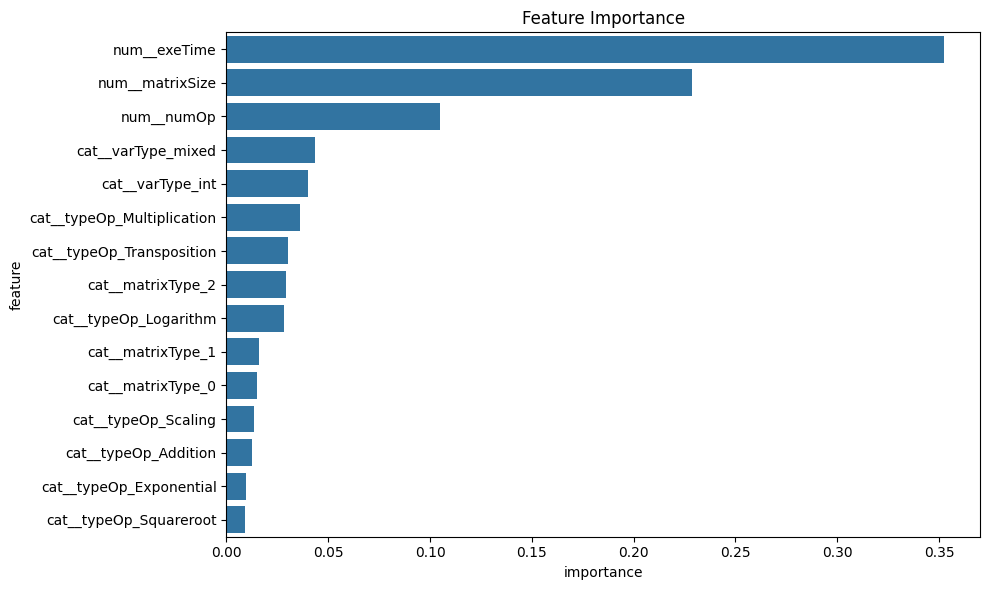


Example prediction:
Predicted optimal thread count: 8


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib
import warnings
warnings.filterwarnings('ignore')

def load_data(filepath='dataset_v1.csv'):
    try:
        df = pd.read_csv(filepath)
        print(f"Data loaded successfully with {df.shape[0]} samples and {df.shape[1]} features.")
        return df
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

def preprocess_data(df):
    if df.isnull().sum().sum() > 0:
        print("Found missing values. Filling numerical with median and categorical with mode.")
        num_features = ['matrixSize', 'numOp', 'numVar', 'exeTime']
        for col in num_features:
            if col in df.columns and df[col].isnull().sum() > 0:
                df[col] = df[col].fillna(df[col].median())
        cat_features = ['typeOp', 'varType', 'isIterative', 'memoryPattern', 'complexity', 'matrixType']
        for col in cat_features:
            if col in df.columns and df[col].isnull().sum() > 0:
                df[col] = df[col].fillna(df[col].mode()[0])
    num_features = ['matrixSize', 'numOp', 'numVar', 'exeTime']
    for col in num_features:
        if col in df.columns:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
            df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    for col in num_features:
        if col in df.columns:
            skew = df[col].skew()
            if skew > 1:
                df[col] = np.log1p(df[col] + 1e-6)
                print(f"Log-transformed {col} due to skewness: {skew:.2f}")
    cat_features = ['typeOp', 'varType', 'isIterative', 'memoryPattern', 'complexity', 'matrixType']
    for col in cat_features:
        if col in df.columns:
            df[col] = df[col].astype(str)
    return df

def create_feature_transformer():
    numerical_features = ['matrixSize', 'numOp', 'numVar', 'exeTime']
    categorical_features = ['typeOp', 'varType', 'isIterative', 'memoryPattern', 'complexity', 'matrixType']
    numerical_transformer = StandardScaler()
    categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_features),
            ('cat', categorical_transformer, categorical_features)
        ],
        remainder='drop'
    )
    return preprocessor

def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    y_pred_rounded = np.round(y_pred)
    exact_accuracy = np.mean(y_pred_rounded == y_true)
    off_by_one_accuracy = np.mean(np.abs(y_pred_rounded - y_true) <= 1)
    return {
        'rmse': rmse,
        'r2': r2,
        'mae': mae,
        'exact_accuracy': exact_accuracy,
        'off_by_one_accuracy': off_by_one_accuracy
    }

def run_grid_search(X_train, y_train, X_test, y_test):
    preprocessor = create_feature_transformer()
    models = {
        'Random Forest': RandomForestRegressor(random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(random_state=42),
        'Ridge': Ridge(random_state=42),
        'Lasso': Lasso(random_state=42),
        'SVR': SVR()
    }
    param_grids = {
        'Random Forest': {
            'model__n_estimators': [50, 100, 200],
            'model__max_depth': [None, 10, 20],
            'model__min_samples_split': [2, 5]
        },
        'Gradient Boosting': {
            'model__n_estimators': [50, 100, 200],
            'model__learning_rate': [0.01, 0.1],
            'model__max_depth': [3, 5]
        },
        'Ridge': {
            'model__alpha': [0.1, 1.0, 10.0]
        },
        'Lasso': {
            'model__alpha': [0.001, 0.01, 0.1]
        },
        'SVR': {
            'model__C': [0.1, 1, 10],
            'model__kernel': ['linear', 'rbf']
        }
    }
    grid_search_results = {}
    best_score = float('inf')
    best_model_name = None
    best_model = None
    for name, model in models.items():
        print(f"\nRunning grid search for {name}...")
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ])
        grid_search = GridSearchCV(
            pipeline,
            param_grids[name],
            cv=5,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1
        )
        grid_search.fit(X_train, y_train)
        best_pipeline = grid_search.best_estimator_
        y_pred = best_pipeline.predict(X_test)
        results = evaluate_model(y_test, y_pred)
        grid_search_results[name] = {
            'pipeline': best_pipeline,
            'params': grid_search.best_params_,
            'results': results
        }
        if results['rmse'] < best_score:
            best_score = results['rmse']
            best_model_name = name
            best_model = best_pipeline
    return grid_search_results, best_model_name, best_model

def save_model(model, filepath='optimal_thread_predictor.pkl'):
    joblib.dump(model, filepath)
    print(f"Model saved to {filepath}")

def predict_optimal_thread(model, sample_data):
    if not isinstance(sample_data, pd.DataFrame):
        if isinstance(sample_data, dict):
            sample_data = pd.DataFrame([sample_data])
        else:
            raise TypeError("sample_data must be a DataFrame or dictionary")
    prediction = model.predict(sample_data)
    return np.round(prediction).astype(int)

def plot_feature_importance(model, preprocessor, feature_names):
    if hasattr(model, 'named_steps') and 'model' in model.named_steps:
        final_model = model.named_steps['model']
    else:
        final_model = model
    if hasattr(final_model, 'feature_importances_'):
        if hasattr(preprocessor, 'get_feature_names_out'):
            feature_names_out = preprocessor.get_feature_names_out()
        else:
            feature_names_out = [f"feature_{i}" for i in range(len(final_model.feature_importances_))]
        importance_df = pd.DataFrame({
            'feature': feature_names_out,
            'importance': final_model.feature_importances_
        })
        importance_df = importance_df.sort_values('importance', ascending=False)
        plt.figure(figsize=(10, 6))
        sns.barplot(x='importance', y='feature', data=importance_df.head(15))
        plt.title('Feature Importance')
        plt.tight_layout()
        plt.show()
    else:
        print("This model doesn't support feature importance visualization")

def main():
    df = load_data()
    if df is None:
        return
    df = preprocess_data(df)
    X = df.drop('optimalThreads', axis=1)
    y = df['optimalThreads']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")
    grid_search_results, best_model_name, best_model = run_grid_search(X_train, y_train, X_test, y_test)
    print("\nModel Evaluation Results:")
    print(f"{'Model':<20} {'RMSE':<10} {'R²':<10} {'MAE':<10} {'Off-by-1':<10} {'Exact':<10}")
    print("-" * 70)
    for name in grid_search_results.keys():
        results = grid_search_results[name]['results']
        print(f"{name:<20} {results['rmse']:<10.4f} {results['r2']:<10.4f} {results['mae']:<10.4f} "
              f"{results['off_by_one_accuracy']:<10.4f} {results['exact_accuracy']:<10.4f}")
    print("\nConclusion:")
    print(f"The {best_model_name} model performs best for predicting optimal thread counts.")
    print("To use this model in production, you can:")
    print("1. Load the saved model using 'joblib.load('optimal_thread_predictor.pkl')'")
    print("2. Use the predict_optimal_thread() function for new data points")
    save_model(best_model)
    if best_model_name in ['Random Forest', 'Gradient Boosting']:
        preprocessor = best_model.named_steps['preprocessor']
        feature_names = X.columns.tolist()
        plot_feature_importance(best_model, preprocessor, feature_names)
    print("\nExample prediction:")
    sample = {
        'matrixSize': 1000,
        'numOp': 5000000,
        'numVar': 10,
        'exeTime': 0.5,
        'typeOp': 'Multiplication',
        'varType': 'float',
        'isIterative': '1',
        'memoryPattern': '0',
        'complexity': '3.0',
        'matrixType': '0'
    }
    sample_df = pd.DataFrame([sample])
    predicted_threads = predict_optimal_thread(best_model, sample_df)
    print(f"Predicted optimal thread count: {predicted_threads[0]}")

if __name__ == "__main__":
    main()
